In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1-Anlyse descriptive 

In [27]:
# Charger le dataset
Dataset = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')

Dataset.head()
Dataset.info()
Dataset.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

## Structure du dataset

Le dataset contient 9471 observations et 17 variables, dont la majorité sont numériques. Les colonnes `Date` et `Time` sont de type texte.

On observe la présence de valeurs manquantes (environ 114 par colonne). De plus, les colonnes `Unnamed: 15` et `Unnamed: 16` sont vides et seront supprimées.

Ces éléments montrent qu’un prétraitement des données est nécessaire avant l’analyse.


In [28]:
# Remplacer les valeurs manquantes codées en -200
Dataset.replace(-200, np.nan, inplace=True)

# Supprimer les colonnes vides
Dataset = Dataset.drop(columns=["Unnamed: 15", "Unnamed: 16"])

# Vérifier les valeurs manquantes
Dataset.isna().sum()

Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

In [29]:
Dataset.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


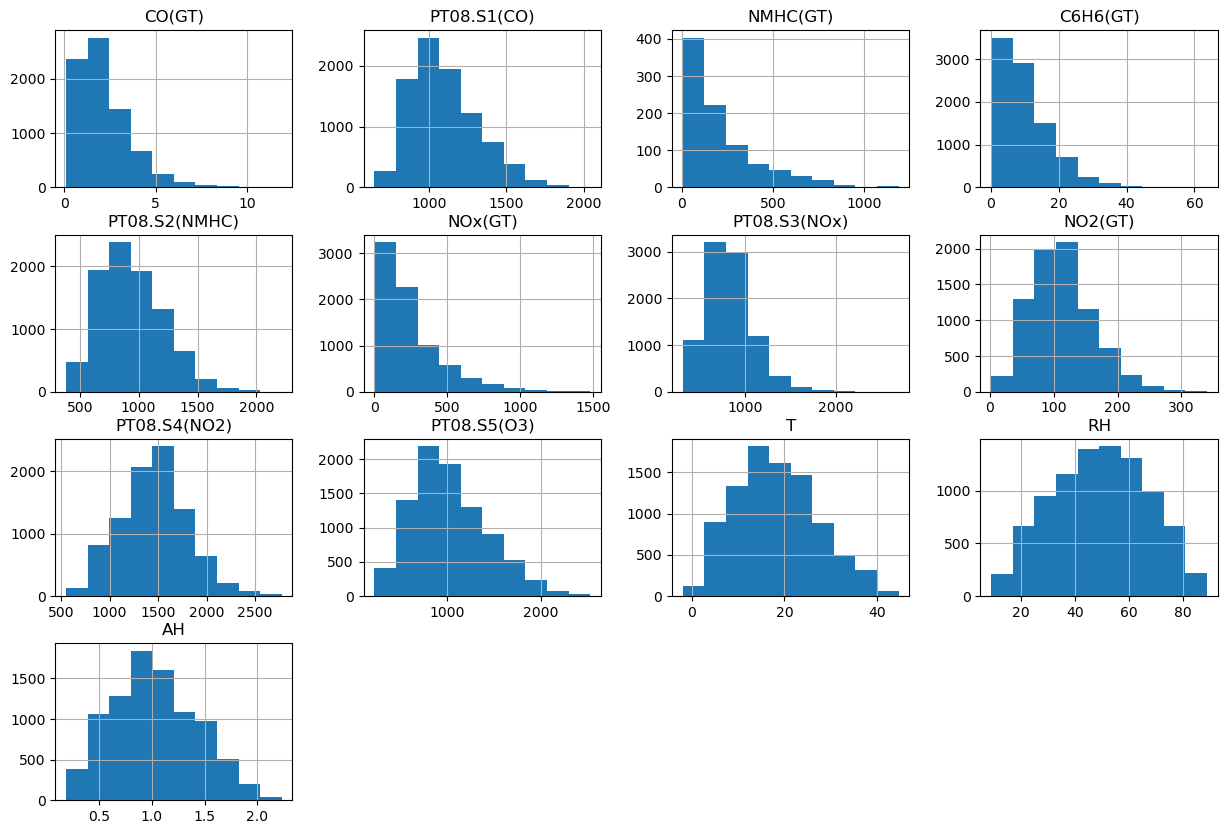

In [30]:
Dataset.hist(figsize=(15,10))
plt.show()

## Distribution des variables

Les histogrammes montrent que la plupart des variables présentent une distribution asymétrique, notamment les polluants (CO, NOx, Benzene), avec une majorité de valeurs faibles et quelques valeurs élevées.

Cela suggère la présence de pics de pollution ponctuels. En revanche, certaines variables comme la température (T) ou l’humidité (RH) ont une distribution plus équilibrée.

Ces différences de distribution devront être prises en compte lors de la modélisation.


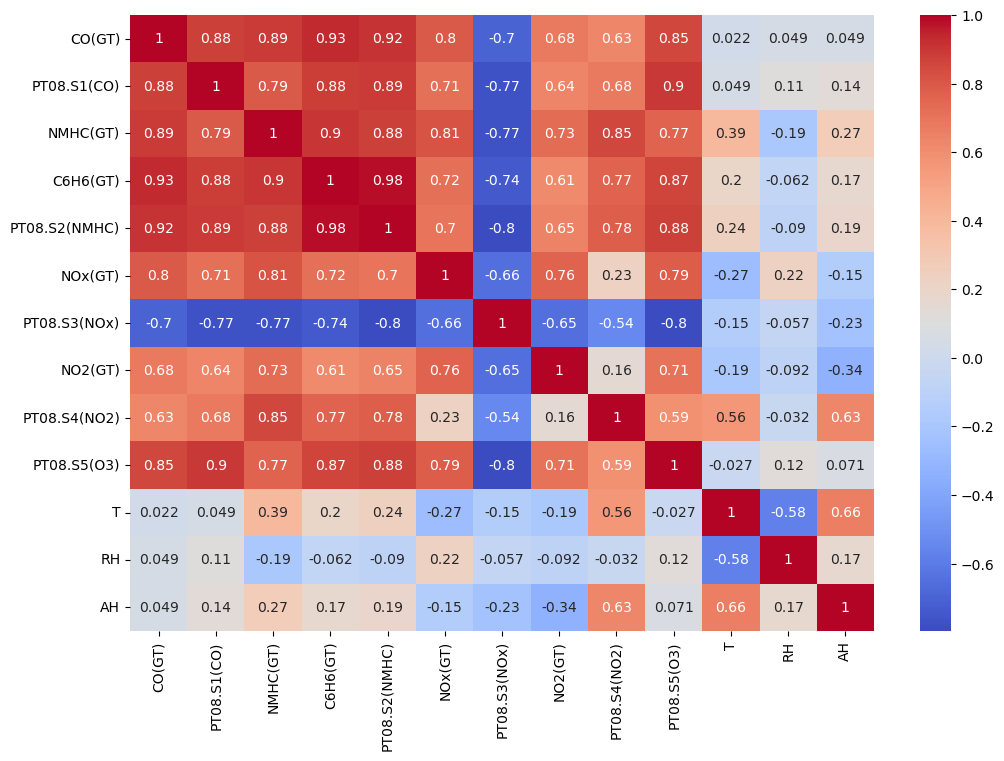

In [31]:
Dataset_numeric = Dataset.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(Dataset_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

## Analyse des corrélations

La matrice de corrélation montre des relations fortes entre certaines variables. On observe notamment une forte corrélation positive entre les capteurs (PT08) et les concentrations de polluants comme CO, C6H6 et NOx.

Certaines variables présentent également des corrélations négatives, notamment avec le capteur PT08.S3(NOx).

Ces résultats indiquent que les capteurs sont pertinents pour la prédiction des polluants, ce qui sera utile pour la modélisation.


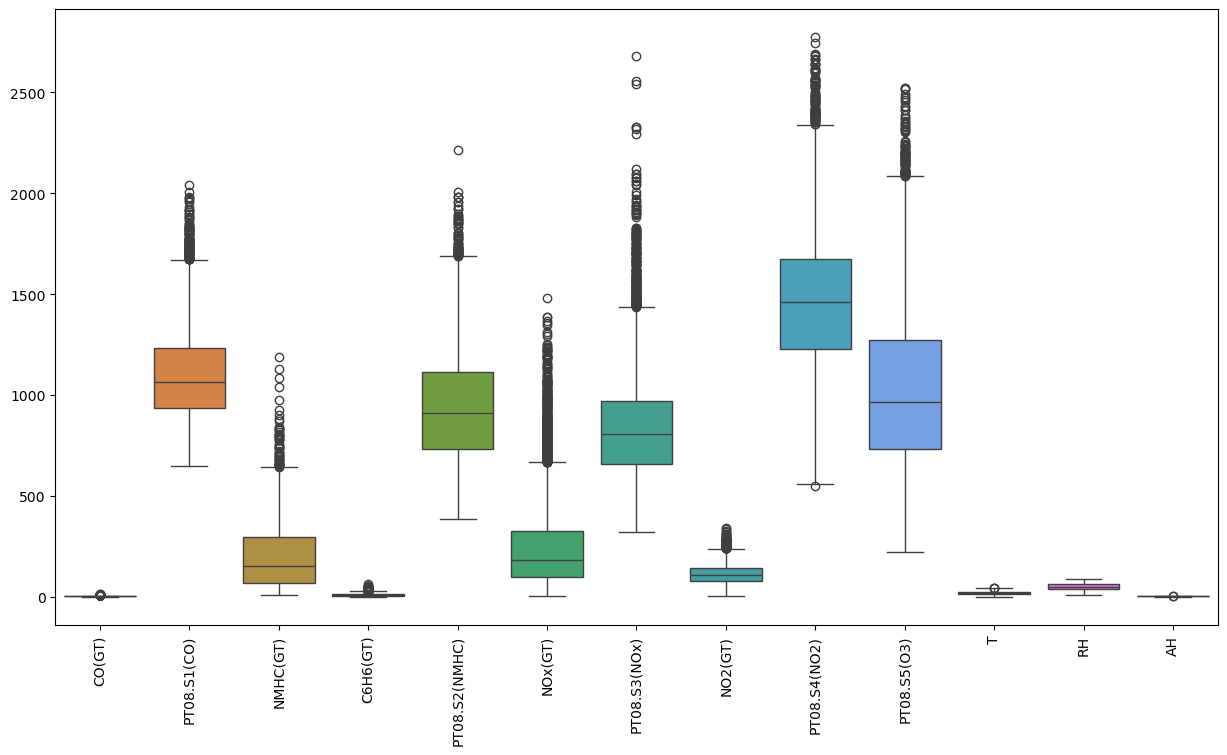

In [34]:
plt.figure(figsize=(15,8))
sns.boxplot(data=Dataset.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()

## Détection des valeurs aberrantes

Les boxplots montrent la présence de nombreuses valeurs aberrantes dans plusieurs variables, notamment les polluants et les capteurs. Cela indique une forte variabilité des données, probablement liée à des pics de pollution.

Les variables environnementales comme la température et l’humidité présentent moins de dispersion.


In [32]:
# Corriger le format de l'heure
Dataset['Time'] = Dataset['Time'].str.replace('.', ':', regex=False)

# Créer la variable datetime
Dataset['Datetime'] = pd.to_datetime(
    Dataset['Date'] + ' ' + Dataset['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Trier les données
Dataset = Dataset.sort_values('Datetime')

# Variables cibles
y = Dataset[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]

# Variables explicatives
X = Dataset.drop(columns=['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'Date', 'Time', 'Datetime'])

## Préparation des données

Les colonnes `Date` et `Time` ont été combinées pour créer une variable temporelle unique. Une correction du format de l’heure a d’abord été nécessaire afin de permettre la conversion en format datetime.

Les données ont ensuite été triées chronologiquement. Enfin, les variables cibles et les variables explicatives ont été définies pour préparer la suite de l’analyse.


In [33]:
train_size = int(len(Dataset) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(7576, 9) (1895, 9)
(7576, 4) (1895, 4)


## Séparation des données

Les données ont été divisées en un ensemble d’entraînement (80%) et un ensemble de test (20%) en respectant l’ordre chronologique. Cela permet d’éviter toute fuite d’information et de conserver la structure temporelle des données.
